# Professional Real Estate Data Preprocessing for BI
### Target: Executive Level Reporting (US Real Estate Standards)

This notebook transforms raw real estate data into a high-quality dataset optimized for Power BI dashboards. Key focuses: Valuation metrics, data integrity, and analytical depth.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load data with correct separator and decimal handling
df = pd.read_csv('Real Estate Dataset.csv', sep=';', decimal=',', encoding='utf-8')

# Normalizing column names to avoid issues like ' district'
df.columns = df.columns.str.strip()

# Remove duplicates in-place
df.drop_duplicates(inplace=True)

print(f"Initial Shape: {df.shape}")
df.head()

Initial Shape: (14969, 27)


,name_nsi,price,index,environment,quality_of_living,safety,transport,services,relax,condition,...,last_reconstruction,total_floors,floor,lift,balkonies,loggia,cellar,type,rooms,district
0,Semerovo,42000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Original condition,...,NaN,NaN,NaN,0,NaN,NaN,0,3-room apartment,3,Nové Zámky
1,Semerovo,42000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Original condition,...,NaN,2.0,NaN,0,NaN,NaN,0,3-room apartment,3,Nové Zámky
2,Štúrovo,107000,8.3,NaN,NaN,NaN,NaN,NaN,NaN,Partial reconstruction,...,NaN,5.0,3.0,0,NaN,NaN,0,1-room apartment,1,Nové Zámky
3,Štúrovo,105000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Complete reconstruction,...,NaN,7.0,4.0,1,NaN,NaN,0,3-room apartment,3,Nové Zámky
4,Štúrovo,82000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Partial reconstruction,...,2018.0,NaN,2.0,0,NaN,NaN,0,2-room apartment,2,Nové Zámky


## 1. Data Cleaning & Feature Selection

In [2]:
# Ensure numeric types for critical columns
int_cols = ['year_built', 'last_reconstruction', 'total_floors', 'floor', 'rooms', 'lift', 'cellar', 'balkonies', 'loggia']
for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filter unrealistic values - Using NaN for errors to avoid statistical bias
df.loc[df['area'] < 20, 'area'] = np.nan
df.loc[(df['year_built'] < 1850) | (df['year_built'] >= 2024), 'year_built'] = np.nan

# Precise Row Cleaning: Dropping rows with missing critical information
critical_subset = ['rooms', 'price', 'district', 'name_nsi', 'area']
df.dropna(axis=0, how='any', subset=critical_subset, inplace=True)

print(f"Cleaning applied. Current Shape: {df.shape}")

Cleaning applied. Current Shape: (14176, 27)


## 2. Professional Amenity Handling

In [3]:
# 1. Amenities: If it's NaN, we can assume it's missing and create a binary indicator for it
amenity_cols = ['balkonies', 'loggia', 'lift', 'cellar', 'total_floors', 'last_reconstruction', 'year_built', 'floor']
for col in amenity_cols:
    df[f'{col}_unknown'] = df[col].isna().astype(int)

# 2. Categorical filling for descriptive columns
cat_cols = ['condition', 'construction_type', 'certificate', 'orientation']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

print("Amenity handling and smart imputation completed.")

Amenity handling and smart imputation completed.


## 3. High-Value Feature Engineering for Power BI (Optional)

In [4]:
# Price per Square Meter (KPI #1)
df['price_per_sqm'] = df['price'] / df['area']

# Building Age & Status
df['building_age'] = 2024 - df['year_built']
df['age_bucket'] = pd.cut(
    df['building_age'],
    bins=[0,10,20,40,80,200],
    labels=['0-10','11-20','21-40','41-80','80+']
)
df['age_bucket'] = df['age_bucket'].astype('object').fillna('Unknown')

# Market Segmentation
df['price_segment'] = pd.cut(df['price'], bins=[0,150000,300000,600000,10000000], labels=['Budget','Economy','Premium','Luxury'])
df['size_segment'] = pd.cut(df['area'], bins=[0, 45, 75, 110, 1000], labels=['Studio', 'Small', 'Standard', 'Large'])

print("Advanced features generated. Ready for dashboard slicers.")

Advanced features generated. Ready for dashboard slicers.


## 4. Visual Optimization (Outlier Capping)
Prevents skewed charts in Power BI.

In [5]:
def cap_values(s, q=0.98):
    limit = s.quantile(q)
    return s.clip(upper=limit)

df['price_visual'] = cap_values(df['price'])
df['area_visual'] = cap_values(df['area'])

print("Outliers capped for better BI visualization.")

Outliers capped for better BI visualization.


<Axes: >

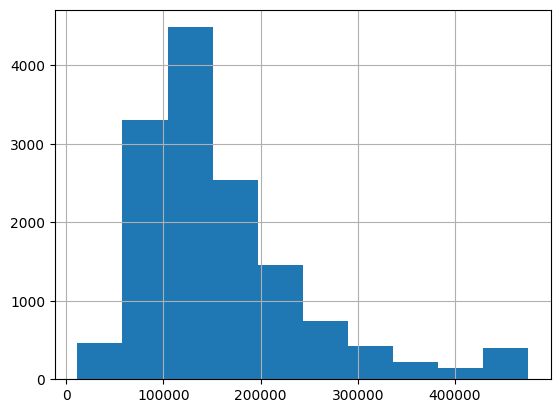

In [6]:
df['price_visual'].hist() 

In [7]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets

def plot_histogram(selected_district):
    df_filtered = df[df['district'] == selected_district]
    
    plt.figure(figsize=(8,5))
    plt.hist(df_filtered['price_visual'], bins=20)
    plt.title(f'Price Distribution - {selected_district}')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.show()

interact(
    plot_histogram,
    selected_district=widgets.Dropdown(
        options=sorted(df['district'].unique()),
        description='District:'
    )
);

interactive(children=(Dropdown(description='District:', options=('Banská Bystrica', 'Banská Štiavnica', 'Barde…

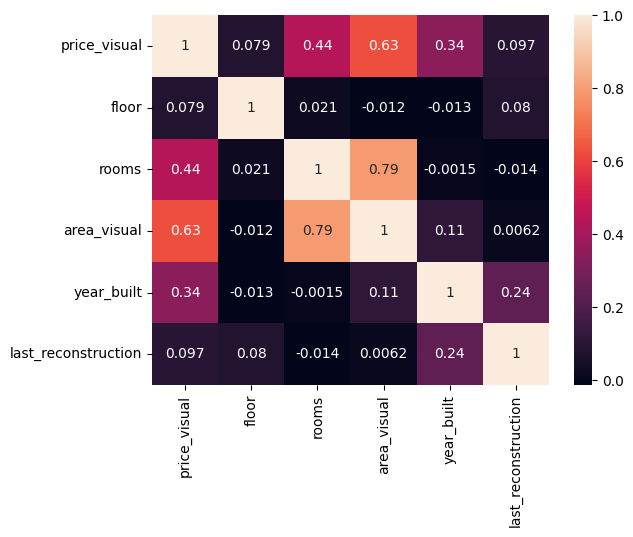

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['price_visual','floor','rooms','area_visual','year_built','last_reconstruction']

corr = df[cols].corr()
#['price_visual']]
sns.heatmap(corr, annot=True)

plt.show()

In [10]:
from ipywidgets import interact

cols = ['price_visual','floor','rooms','area_visual','year_built','last_reconstruction']

def plot_corr(selected_district):
    df_filtered = df[df['district'] == selected_district]
    corr = df_filtered[cols].corr()
    
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation - {selected_district}')
    plt.show()

interact(plot_corr, selected_district=df['district'].unique());

interactive(children=(Dropdown(description='selected_district', options=('Nové Zámky', 'Šaľa', 'Piešťany', 'Se…

In [11]:
from ipywidgets import interact

def plot_by_district(selected_district):
    df_filtered = df[df['district'] == selected_district]
    
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        data=df_filtered,
        x='area_visual',
        y='price_visual',
        alpha=0.7
    )
    plt.title(f'Price vs Area - {selected_district}')
    plt.show()

interact(plot_by_district, 
         selected_district=df['district'].unique());

interactive(children=(Dropdown(description='selected_district', options=('Nové Zámky', 'Šaľa', 'Piešťany', 'Se…

## 5. Export to BI

In [51]:
df.to_csv('BI_Ready_Real_Estate.csv', index=False, encoding='utf-8')
print("Process complete. File 'BI_Ready_Real_Estate.csv' saved successfully.")


Process complete. File 'BI_Ready_Real_Estate.csv' saved successfully.
